In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df=pd.read_csv('data.csv')
df

,label,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data=np.array(df)
data

array([[5, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [4, 0, 0, ..., 0, 0, 0],
       ...,
       [4, 0, 0, ..., 0, 0, 0],
       [5, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0]])

In [4]:
data.shape

(70000, 785)

In [5]:
rows,cols=data.shape
test_size=int(rows*.8)
train= data[: test_size].T
test=data[test_size:].T
X_train,y_train=train[1:],train[0]
X_test,y_test=test[1:],test[0]
# train.shape
# 70000*.8

In [6]:
print(X_train.shape)

(784, 56000)


In [7]:
print(X_train)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [8]:
print(y_train)

[5 0 4 ... 2 3 3]


In [22]:
def init_params():
    w1=np.random.rand(10,784) - 0.5
    b1=np.random.rand(10,1) - 0.5
    w2=np.random.rand(10,10) - 0.5
    b2=np.random.rand(10,1) - 0.5
    return w1,b1,w2,b2

def ReLU(z):
    return np.maximum(0,z)

def softmax(z):
    # shift_z= z- np.max(z,axis=-1,keepdims=True)
    # a= np.exp(shift_z) / np.sum(np.exp(shift_z))
    a = np.exp(z) / sum(np.exp(z))
    return a

def forward_propagation(w1,b1,w2,b2,x):
    z1=w1.dot(x)+b1
    a1=ReLU(z1)
    z2=w2.dot(a1)+b2
    a2=softmax(z2)
    return z1,a1,z2,a2

def one_hot(y):
    one_hot_y=np.zeros((y.size,y.max()+1))
    one_hot_y[np.arange(y.size),y]=1
    one_hot_y=one_hot_y.T
    return one_hot_y

def dReLU(z):
    return z>0

def backward_propagation(z1,a1,z2,a2,w1,w2,x,y):
    m=y.size
    onehoty=one_hot(y)
    dz2=a2-onehoty
    dw2= 1/m * dz2.dot(a1.T)
    db2= 1/m * np.sum(dz2)
    dz1= w2.T.dot(dz2) + dReLU(z1)
    dw1= 1/m * dz1.dot(x.T)
    db1= 1/m * np.sum(dz1)
    return db1,dw1,db2,dw2
def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2,alpha):
    w1=w1-alpha*dw1
    b1=b1-alpha*db1
    w2=w2-alpha*dw2
    b2=b2-alpha*db2
    return w1,b1,w2,b2
    

In [10]:
def get_prediction(a):
    return np.argmax(a,0)
def get_accuracy(prediction, y):
    print(prediction, y)
    return np.sum(prediction == y)/y.size

def gradient_descent(x, y, iterations,alpha):
    w1,b1,w2,b2 = init_params()
    for i in range(iterations):
        # print(i)
        z1,a1,z2,a2=forward_propagation(w1,b1,w2,b2,x)
        db1,dw1,db2,dw2= backward_propagation(z1,a1,z2,a2,w1,w2,x,y)
        w1,b1,w2,b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2,alpha)
        if i%50 == 0:
            print('iteration - ',i,' : ')
            print('accuracy : ',get_accuracy(get_prediction(a2),y))
    return w1, b1, w2, b2

In [ ]:
w1,b1,w2,b2 = gradient_descent(X_train,y_train,500,0.1)

In [19]:
def predict(x,w1,b1,w2,b2):
    _,_,_,a2=forward_propagation(w1,b1,w2,b2,x)
    predictions=get_prediction(a2)
    return predictions
def test_pred(index,w1,b1,w2,b2):
    curr_img=X_train[:,index,None]
    pred=predict(X_train[:,index,None],w1,b1,w2,b2)
    label=y_train[index]
    print('prediction : ',pred)
    print('label : ',label)
    curr_img=curr_img.reshape((28,28))*255
    plt.gray()
    plt.imshow(curr_img,interpolation='nearest')
    plt.show()

prediction :  [0]
label :  0


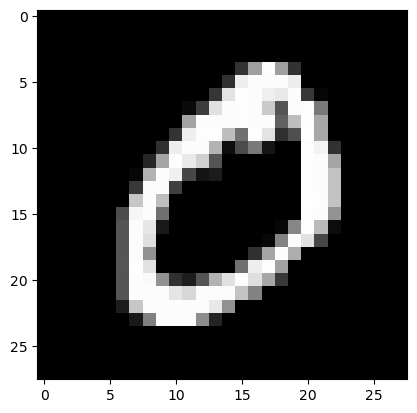

In [25]:
test_pred(1,w1,b1,w2,b2)